# BSDS500 — Clustering Algorithm Comparison
## 12 Segmentation Algorithms (incl. Simulated Annealing & Genetic Algorithm) evaluated with ARI, NMI, Silhouette, SSE & Time

This notebook:
1. Loads images from the BSDS500 dataset (or a built-in fallback if the path is not found).
2. Runs **12 clustering algorithms** on each image: KMeans, KMedoids, DBSCAN, DIANA, 5 Agglomerative linkages, BIRCH, plus the two new **metaheuristics: Simulated Annealing (SA)** and **Genetic Algorithm (GA)**.
3. Computes exactly five measures:

| Metric | Type | Meaning | Better |
|---|---|---|---|
| **ARI** | external | agreement with human ground truth (Adjusted Rand Index) | higher |
| **NMI** | external | shared information with ground truth | higher |
| **Silhouette** | internal | compactness / separation of clusters | higher |
| **SSE** | internal | sum of squared distances of pixels to their cluster centre | lower |
| **Time (s)** | efficiency | runtime of the algorithm | lower |

4. Produces a visual segmentation grid per image, formatted tables, an `.xlsx` report, comparison charts and an auto-generated summary.

In [1]:
import os
import sys
import time
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform, cdist
from skimage import io as skio, color, transform, data, segmentation
from sklearn.cluster import KMeans, DBSCAN, Birch
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

warnings.filterwarnings("ignore")

In [2]:
def log(msg):
    """Print immediately (flushed) so progress is visible even if something
    downstream hangs or errors out."""
    print(msg, flush=True)

## Configuration
Change `BASE_DIR`, `SPLIT`, and `IMAGE_IDS` to point to your BSDS500 dataset.  
If the paths don't exist the notebook falls back to two built-in scikit-image photos.

In [3]:
BASE_DIR = r"C:\Users\BIT\Desktop\IED1000823\SML2\Berkley"
SPLIT = "test"
IMAGE_IDS = ["100007", "100039"]
RESIZE_DIM = (60, 60)
RANDOM_STATE = 42
OUTPUT_DIR = "clustering_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Data Loading — BSDS500 or Fallback

In [4]:
def bsds_available():
    """Return True if the BSDS500 image & ground-truth folders exist."""
    img_dir = os.path.join(BASE_DIR, "images", SPLIT)
    gt_dir  = os.path.join(BASE_DIR, "ground_truth", SPLIT)
    return os.path.isdir(img_dir) and os.path.isdir(gt_dir)


def load_bsds_image_and_gt(image_id):
    """Load an image and its first-annotator ground-truth from BSDS500."""
    img_path = os.path.join(BASE_DIR, "images", SPLIT, f"{image_id}.jpg")
    gt_path  = os.path.join(BASE_DIR, "ground_truth", SPLIT, f"{image_id}.mat")

    img = skio.imread(img_path)
    if img.ndim == 2:
        img = color.gray2rgb(img)

    mat = loadmat(gt_path)
    gt_struct = mat["groundTruth"][0]
    seg = gt_struct[0]["Segmentation"][0][0]
    return img, seg.astype(int)


def load_fallback_image_and_gt(image_id):
    """Load a built-in scikit-image sample photo and create a reference
    segmentation using Felzenszwalb's algorithm (provides a reasonable
    pseudo-ground-truth when BSDS500 is unavailable)."""
    if image_id == "astronaut":
        img = data.astronaut()
    elif image_id == "coffee":
        img = data.coffee()
    else:
        raise ValueError(f"Unknown fallback image: {image_id}")
    seg = segmentation.felzenszwalb(img, scale=200, sigma=0.5, min_size=100)
    return img, seg.astype(int)

## Feature Extraction (CIELAB + spatial position)

In [5]:
def extract_features(img, resize_dim=RESIZE_DIM):
    """Down-samples the image, converts to CIELAB colour space, appends
    normalized (x, y) pixel position, then standardizes all 5 dims.
    Returns (features [n_pixels x 5], (h, w))."""
    small = transform.resize(img, resize_dim, anti_aliasing=True)
    lab = color.rgb2lab(small)
    h, w, _ = lab.shape

    xs, ys = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
    feats = np.dstack([lab, xs, ys]).reshape(-1, 5)
    feats = StandardScaler().fit_transform(feats)
    return feats, (h, w)

## Clustering Algorithm Implementations

In [6]:
def run_kmeans(feats, k):
    return KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(feats)


def run_kmedoids(feats, k, max_iter=50):
    """Simple PAM-style K-Medoids (no extra dependency needed)."""
    rng = np.random.RandomState(RANDOM_STATE)
    n = feats.shape[0]
    D = squareform(pdist(feats))
    medoids = rng.choice(n, k, replace=False)

    for _ in range(max_iter):
        labels = np.argmin(D[:, medoids], axis=1)
        new_medoids = medoids.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                continue
            sub = D[np.ix_(members, members)]
            new_medoids[c] = members[np.argmin(sub.sum(axis=1))]
        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids

    return np.argmin(D[:, medoids], axis=1)


def run_dbscan(feats, k=None, min_samples=8):
    """k is ignored -- DBSCAN infers cluster count itself. eps is picked
    automatically from the median k-NN distance (a standard heuristic)."""
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(feats)
    dists, _ = nbrs.kneighbors(feats)
    eps = np.median(dists[:, -1])
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(feats)
    labels[labels == -1] = labels.max() + 1  # fold noise into its own cluster
    return labels


def run_diana(feats, k):
    """DIANA = divisive (top-down) hierarchical clustering via bisecting
    k-means approximation."""
    n = feats.shape[0]
    clusters = [np.arange(n)]

    while len(clusters) < k:
        sse = [((feats[idx] - feats[idx].mean(axis=0)) ** 2).sum() for idx in clusters]
        split_i = int(np.argmax(sse))
        idx = clusters.pop(split_i)
        sub_labels = KMeans(n_clusters=2, n_init=5, random_state=RANDOM_STATE).fit_predict(feats[idx])
        clusters.append(idx[sub_labels == 0])
        clusters.append(idx[sub_labels == 1])

    labels = np.empty(n, dtype=int)
    for cid, idx in enumerate(clusters):
        labels[idx] = cid
    return labels


def run_agglomerative(feats, k, method):
    """Agglomerative (bottom-up) hierarchical clustering using scipy."""
    Z = linkage(feats, method=method)
    labels = fcluster(Z, t=k, criterion="maxclust")
    return labels - 1


def run_birch(feats, k):
    return Birch(n_clusters=k).fit_predict(feats)

## New: Simulated Annealing (SA) and Genetic Algorithm (GA) clustering

Both are **metaheuristic optimisers**. They search for the best set of *k* cluster centres (a *solution*) that **minimises SSE** (the same objective as K-Means), but without K-Means' gradient-like update step.

**Simulated Annealing**
1. Start with *k* random pixels as centres; compute cost = SSE.
2. Perturb one random centre by Gaussian noise (step size shrinks as the system cools).
3. If the new cost is lower → accept. If higher → accept with probability `exp(-ΔE / T)` (this lets it escape local minima).
4. Cool the temperature geometrically `T ← α·T`; keep the best solution ever seen.

**Genetic Algorithm**
1. *Population*: 40 candidate solutions (each = *k* centres, chosen from random pixels).
2. *Fitness*: SSE (lower = fitter).
3. *Selection*: tournament of 3. *Crossover*: each child inherits every centre from parent 1 or parent 2 at random. *Mutation*: Gaussian noise on some centres.
4. *Elitism*: the 2 best solutions always survive. Repeat for 100 generations.

In [7]:
CONVERGENCE = {}   # stores cost-vs-iteration curves so we can plot SA / GA convergence later

def _assign(feats, C):
    return np.argmin(cdist(feats, C, "sqeuclidean"), axis=1)

def run_sa(feats, k, n_iter=4000, seed=RANDOM_STATE):
    """Simulated Annealing clustering: optimise k centroids to minimise SSE."""
    rng = np.random.default_rng(seed)
    n, d = feats.shape
    C = feats[rng.choice(n, k, replace=False)].copy()        # random initial solution
    D = cdist(feats, C, "sqeuclidean")                        # n x k distance table
    cost = D.min(axis=1).sum()
    T0 = 0.05 * cost                                          # initial temperature
    T  = T0
    alpha = (1e-3) ** (1.0 / n_iter)                          # geometric cooling: T ends at 0.1% of T0
    best_C, best_cost = C.copy(), cost
    history = [cost]

    for _ in range(n_iter):
        j = rng.integers(k)                                   # pick one centroid to modify
        if rng.random() < 0.10:
            c_new = feats[rng.integers(n)]                    # occasional jump to a random pixel
        else:
            step = 0.05 + 0.5 * (T / T0)                      # step shrinks as it cools
            c_new = C[j] + rng.normal(0, step, d)
        old_col = D[:, j].copy()
        D[:, j] = ((feats - c_new) ** 2).sum(axis=1)          # only recompute the changed column
        new_cost = D.min(axis=1).sum()
        dE = new_cost - cost
        if dE < 0 or rng.random() < np.exp(-dE / T):          # Metropolis acceptance rule
            C[j], cost = c_new, new_cost
            if cost < best_cost:
                best_C, best_cost = C.copy(), cost
        else:
            D[:, j] = old_col                                 # reject: restore
        T *= alpha                                            # cooling
        history.append(best_cost)

    CONVERGENCE["SA"] = history
    return _assign(feats, best_C)


def run_ga(feats, k, pop_size=40, generations=100, tournament=3, crossover_rate=0.9,
           mutation_rate=0.2, mutation_sigma=0.3, elite=2, seed=RANDOM_STATE):
    """Genetic Algorithm clustering: evolve a population of centroid sets to minimise SSE."""
    rng = np.random.default_rng(seed)
    n, d = feats.shape
    sse_of = lambda C: cdist(feats, C, "sqeuclidean").min(axis=1).sum()

    pop = np.stack([feats[rng.choice(n, k, replace=False)] for _ in range(pop_size)])  # (P, k, d)
    history, best_C, best_cost = [], None, np.inf

    for g in range(generations):
        fit = np.array([sse_of(c) for c in pop])              # fitness (lower is better)
        order = np.argsort(fit)
        if fit[order[0]] < best_cost:
            best_cost, best_C = fit[order[0]], pop[order[0]].copy()
        history.append(best_cost)

        new_pop = [pop[i].copy() for i in order[:elite]]      # elitism
        sigma = mutation_sigma * (1 - g / generations) + 0.02 # mutation strength decays
        while len(new_pop) < pop_size:
            idx1 = rng.choice(pop_size, tournament); p1 = pop[idx1[np.argmin(fit[idx1])]]   # tournament selection
            idx2 = rng.choice(pop_size, tournament); p2 = pop[idx2[np.argmin(fit[idx2])]]
            if rng.random() < crossover_rate:                 # uniform crossover over centroids
                mask = rng.random(k) < 0.5
                child = np.where(mask[:, None], p1, p2)
            else:
                child = p1.copy()
            m = rng.random(k) < mutation_rate                 # Gaussian mutation
            child[m] += rng.normal(0, sigma, (m.sum(), d))
            r = rng.random(k) < 0.02                          # rare random re-initialisation
            if r.any():
                child[r] = feats[rng.choice(n, r.sum())]
            new_pop.append(child)
        pop = np.stack(new_pop)

    CONVERGENCE["GA"] = history
    return _assign(feats, best_C)

In [8]:
ALGORITHMS = {
    "KMeans":          run_kmeans,
    "KMedoids":        run_kmedoids,
    "DBSCAN":          run_dbscan,
    "DIANA":           run_diana,
    "Agglo-Single":    lambda f, k: run_agglomerative(f, k, "single"),
    "Agglo-Complete":  lambda f, k: run_agglomerative(f, k, "complete"),
    "Agglo-Average":   lambda f, k: run_agglomerative(f, k, "average"),
    "Agglo-Ward":      lambda f, k: run_agglomerative(f, k, "ward"),
    "Agglo-Centroid":  lambda f, k: run_agglomerative(f, k, "centroid"),
    "BIRCH":           run_birch,
    "SimAnnealing":    run_sa,      # NEW
    "GeneticAlgo":     run_ga,      # NEW
}

METRICS = {          # metric name -> True if higher is better
    "ARI": True, "NMI": True, "Silhouette": True, "SSE": False, "Time (s)": False,
}

## Evaluation Metrics
- **ARI / NMI** (external): compare predicted segmentation with the human ground truth.
- **Silhouette** (internal): compactness/separation in the 5-D feature space.
- **SSE** (internal): total squared distance from every pixel to the mean of its own cluster (feature space, lower = tighter clusters).
- **Time**: measured around each algorithm's run.

In [9]:
def compute_sse(feats, labels):
    """Sum of squared errors of every point to the centre (mean) of its own cluster."""
    sse = 0.0
    for c in np.unique(labels):
        pts = feats[labels == c]
        sse += ((pts - pts.mean(axis=0)) ** 2).sum()
    return sse


def compute_metrics(feats, labels, shape, gt):
    """Return ARI, NMI (vs ground truth), Silhouette, SSE (internal) and the resized label image."""
    label_img = labels.reshape(shape)
    resized = transform.resize(
        label_img, gt.shape, order=0, preserve_range=True, anti_aliasing=False
    ).astype(int)

    ari = adjusted_rand_score(gt.flatten(), resized.flatten())
    nmi = normalized_mutual_info_score(gt.flatten(), resized.flatten())

    n_unique = len(np.unique(labels))
    if 1 < n_unique < len(labels):
        try:
            sil = silhouette_score(feats, labels)
        except Exception:
            sil = np.nan
    else:
        sil = np.nan

    sse = compute_sse(feats, labels)
    return ari, nmi, sil, sse, resized

## Visual Segmentation Grid (per image)

In [10]:
def plot_segmentation_grid(image_id, img, gt, k, feats, shape, results_rows):
    """Run every algorithm, collect the 5 metrics, and display a grid of all results."""
    n_algos = len(ALGORITHMS)
    n_cols = 4
    n_rows = int(np.ceil((n_algos + 2) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.3 * n_rows))
    axes = axes.flatten()

    axes[0].imshow(img);  axes[0].set_title(f"{image_id} — original"); axes[0].axis("off")
    axes[1].imshow(gt, cmap="nipy_spectral"); axes[1].set_title(f"ground truth (k={k})"); axes[1].axis("off")

    for i, (name, fn) in enumerate(ALGORITHMS.items(), start=2):
        log(f"  [{image_id}] running {name} ...")
        t0 = time.time()
        labels = fn(feats, k)
        elapsed = time.time() - t0

        ari, nmi_val, sil, sse, seg_img = compute_metrics(feats, labels, shape, gt)
        sil_txt = f"{sil:.3f}" if not np.isnan(sil) else "n/a"
        log(f"    {name}: ARI={ari:.3f}  NMI={nmi_val:.3f}  Sil={sil_txt}  SSE={sse:.1f}  ({elapsed:.2f}s)")

        results_rows.append({
            "Image":      image_id,
            "Algorithm":  name,
            "ARI":        round(ari, 4),
            "NMI":        round(nmi_val, 4),
            "Silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
            "SSE":        round(sse, 2),
            "Time (s)":   round(elapsed, 3),
        })

        axes[i].imshow(seg_img, cmap="nipy_spectral")
        sil_short = f"{sil:.2f}" if not np.isnan(sil) else "n/a"
        axes[i].set_title(f"{name}\nARI={ari:.2f} NMI={nmi_val:.2f} Sil={sil_short}\nSSE={sse:.0f}  T={elapsed:.2f}s", fontsize=9)
        axes[i].axis("off")

    for j in range(n_algos + 2, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"{image_id}_segmentations.png")
    plt.savefig(out_path, dpi=130)
    plt.show()
    plt.close(fig)
    log(f"  [{image_id}] saved grid -> {out_path}\n")

## Formatted Comparison Table Builder (`.xlsx`)
- **Sheet 1 — Per-Image Comparison:** one table per image (ARI, NMI, Silhouette, SSE, Time). Best value in each column is green.
- **Sheet 2 — Average Summary:** metrics averaged over all images with an ARI-based rank.

In [11]:
def build_comparison_xlsx(df, output_path):
    """Create a formatted .xlsx comparison table from the results DataFrame."""
    try:
        import openpyxl
        from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
    except ImportError:
        log("openpyxl not installed — installing ...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])
        import openpyxl
        from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

    wb = openpyxl.Workbook()
    header_font  = Font(name="Arial", bold=True, size=11, color="FFFFFF")
    header_fill  = PatternFill("solid", fgColor="2F5496")
    title_font   = Font(name="Arial", bold=True, size=14, color="2F5496")
    section_font = Font(name="Arial", bold=True, size=12, color="2F5496")
    data_font    = Font(name="Arial", size=11)
    bold_font    = Font(name="Arial", size=11, bold=True)
    best_fill    = PatternFill("solid", fgColor="C6EFCE")
    best_font    = Font(name="Arial", size=11, bold=True, color="006100")
    stripe_fill  = PatternFill("solid", fgColor="D9E2F3")
    side = Side(style="thin", color="B4C6E7")
    border = Border(left=side, right=side, top=side, bottom=side)
    center = Alignment(horizontal="center", vertical="center")
    left   = Alignment(horizontal="left",   vertical="center")

    arrows  = {m: ("↑" if hi else "↓") for m, hi in METRICS.items()}
    formats = {"ARI": "0.0000", "NMI": "0.0000", "Silhouette": "0.0000", "SSE": "0.00", "Time (s)": "0.000"}
    metric_names = list(METRICS.keys())
    last_col = len(metric_names) + 1

    def write_table(ws, start_row, table, headers):
        """table: DataFrame indexed by algorithm with metric columns. Returns next free row."""
        for ci, h in enumerate(headers, 1):
            c = ws.cell(row=start_row, column=ci, value=h)
            c.font, c.fill, c.alignment, c.border = header_font, header_fill, center, border
        best = {m: (table[m].max() if METRICS[m] else table[m].min()) for m in metric_names}
        for i, (alg, row) in enumerate(table.iterrows()):
            r = start_row + 1 + i
            c = ws.cell(row=r, column=1, value=alg)
            c.font, c.alignment, c.border = bold_font, left, border
            if i % 2 == 1: c.fill = stripe_fill
            for ci, m in enumerate(metric_names, 2):
                v = row[m]
                is_nan = pd.isna(v)
                c = ws.cell(row=r, column=ci, value="N/A" if is_nan else float(v))
                c.alignment, c.border = center, border
                if not is_nan:
                    c.number_format = formats[m]
                if (not is_nan) and v == best[m]:
                    c.font, c.fill = best_font, best_fill
                else:
                    c.font = data_font
                    if i % 2 == 1: c.fill = stripe_fill
        return start_row + len(table) + 3

    # ── Sheet 1: per image ──
    ws1 = wb.active
    ws1.title = "Per-Image Comparison"
    ws1.merge_cells(start_row=1, start_column=1, end_row=1, end_column=last_col)
    ws1["A1"] = "Clustering Algorithm Evaluation — Per-Image Metrics"
    ws1["A1"].font = title_font
    ws1["A1"].alignment = center
    ws1.row_dimensions[1].height = 30

    row = 3
    headers = ["Algorithm"] + [f"{m}  {arrows[m]}" for m in metric_names]
    for img_id in df["Image"].unique():
        ws1.merge_cells(start_row=row, start_column=1, end_row=row, end_column=last_col)
        ws1.cell(row=row, column=1, value=f"Image: {img_id}").font = section_font
        ws1.row_dimensions[row].height = 25
        sub = df[df["Image"] == img_id].set_index("Algorithm")[metric_names]
        row = write_table(ws1, row + 1, sub, headers)
    ws1.column_dimensions["A"].width = 20
    for col in "BCDEF":
        ws1.column_dimensions[col].width = 16

    # ── Sheet 2: average ──
    ws2 = wb.create_sheet("Average Summary")
    ws2.merge_cells(start_row=1, start_column=1, end_row=1, end_column=last_col + 1)
    ws2["A1"] = "Average Metrics Across All Images"
    ws2["A1"].font = title_font
    ws2["A1"].alignment = center
    ws2.row_dimensions[1].height = 30

    avg = df.groupby("Algorithm")[metric_names].mean().round(4).reindex(list(ALGORITHMS.keys()))
    avg["Rank (ARI)"] = avg["ARI"].rank(ascending=False, method="min").astype(int)
    hdr = ["Algorithm"] + [f"Avg {m}  {arrows[m]}" for m in metric_names] + ["Rank (ARI)"]
    for ci, h in enumerate(hdr, 1):
        c = ws2.cell(row=3, column=ci, value=h)
        c.font, c.fill, c.alignment, c.border = header_font, header_fill, center, border
    best = {m: (avg[m].max() if METRICS[m] else avg[m].min()) for m in metric_names}
    for i, (alg, rowd) in enumerate(avg.iterrows()):
        r = 4 + i
        c = ws2.cell(row=r, column=1, value=alg)
        c.font, c.alignment, c.border = bold_font, left, border
        if i % 2 == 1: c.fill = stripe_fill
        for ci, m in enumerate(metric_names, 2):
            v = rowd[m]
            c = ws2.cell(row=r, column=ci, value=None if pd.isna(v) else float(v))
            c.number_format, c.alignment, c.border = formats[m], center, border
            if (not pd.isna(v)) and v == best[m]:
                c.font, c.fill = best_font, best_fill
            else:
                c.font = data_font
                if i % 2 == 1: c.fill = stripe_fill
        c = ws2.cell(row=r, column=last_col + 1, value=int(rowd["Rank (ARI)"]))
        c.alignment, c.border = center, border
        c.font, c.fill = (best_font, best_fill) if rowd["Rank (ARI)"] <= 3 else (data_font, PatternFill())
    ws2.column_dimensions["A"].width = 20
    for col in "BCDEFG":
        ws2.column_dimensions[col].width = 19

    lr = 4 + len(avg) + 2
    notes = ["Legend:",
             "ARI = Adjusted Rand Index (vs ground truth; higher = better)",
             "NMI = Normalized Mutual Information (vs ground truth; higher = better)",
             "Silhouette = cluster compactness/separation (higher = better)",
             "SSE = sum of squared errors to cluster centres (lower = better)",
             "Time (s) = runtime of the algorithm (lower = better)",
             "Green = best value in the column"]
    for i, t in enumerate(notes):
        ws2.cell(row=lr + i, column=1, value=t).font = Font(name="Arial", size=10, bold=(i == 0), color="555555")

    wb.save(output_path)
    log(f"Formatted comparison table saved -> {output_path}")

## Styled In-Notebook Table Display

In [12]:
def display_styled_table(df):
    """Show nicely styled tables inline in Jupyter; best value in each column is green."""
    metric_names = list(METRICS.keys())

    def highlight_best(s):
        if s.name not in METRICS:
            return [""] * len(s)
        best = s.max() if METRICS[s.name] else s.min()
        return ["background-color: #C6EFCE; font-weight: bold; color: #006100" if v == best else "" for v in s]

    fmt = {"ARI": "{:.4f}", "NMI": "{:.4f}", "Silhouette": "{:.4f}", "SSE": "{:.2f}",
           "Time (s)": "{:.3f}", "Rank (ARI)": "{:.0f}"}
    css = [
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("color", "#2F5496")]},
        {"selector": "th", "props": [("background-color", "#2F5496"), ("color", "white"), ("text-align", "center")]},
    ]

    for img_id in df["Image"].unique():
        sub = df[df["Image"] == img_id].drop(columns=["Image"]).set_index("Algorithm")
        display(sub.style.apply(highlight_best, subset=metric_names)
                   .format(fmt, na_rep="N/A").set_caption(f"Image: {img_id}").set_table_styles(css))
        print()

    avg = df.groupby("Algorithm")[metric_names].mean().round(4).reindex(list(ALGORITHMS.keys()))
    avg["Rank (ARI)"] = avg["ARI"].rank(ascending=False, method="min").astype(int)
    display(avg.style.apply(highlight_best, subset=metric_names)
               .format(fmt, na_rep="N/A").set_caption("Average Metrics Across All Images").set_table_styles(css))

## Main — Run Everything

In [13]:
def main():
    use_bsds = bsds_available()

    if use_bsds:
        log(f"BSDS500 found at '{BASE_DIR}' — using your real images: {IMAGE_IDS}\n")
        image_list = IMAGE_IDS
        loader = load_bsds_image_and_gt
    else:
        log(f"BSDS500 NOT found at '{BASE_DIR}/images/{SPLIT}'.")
        log("Falling back to 2 built-in scikit-image sample photos.")
        log("Fix BASE_DIR / SPLIT / IMAGE_IDS above and re-run to use your real BSDS500 images.\n")
        image_list = ["astronaut", "coffee"]
        loader = load_fallback_image_and_gt

    results_rows = []
    for image_id in image_list:
        log(f"=== Processing image: {image_id} ===")
        try:
            img, gt = loader(image_id)
        except Exception as e:
            log(f"  FAILED to load {image_id}: {e}")
            traceback.print_exc(file=sys.stdout)
            continue

        k = len(np.unique(gt))
        feats, shape = extract_features(img)
        log(f"  image shape={img.shape}, reference clusters k={k}")
        plot_segmentation_grid(image_id, img, gt, k, feats, shape, results_rows)

    if not results_rows:
        log("\nNo results produced — every image failed. See errors above.")
        return None

    df = pd.DataFrame(results_rows)
    metric_names = list(METRICS.keys())

    # ── Save CSVs ──
    df.to_csv(os.path.join(OUTPUT_DIR, "comparison_results.csv"), index=False)
    for m in metric_names:
        piv = df.pivot(index="Algorithm", columns="Image", values=m).reindex(list(ALGORITHMS.keys()))
        piv.to_csv(os.path.join(OUTPUT_DIR, f"comparison_pivot_{m.split()[0]}.csv"))
    avg_matrix = df.groupby("Algorithm")[metric_names].mean().round(4).reindex(list(ALGORITHMS.keys()))
    avg_matrix.to_csv(os.path.join(OUTPUT_DIR, "evaluation_matrix.csv"))

    # ── Console summary ──
    log("\n=== Full Results Table ===")
    log(df.to_string(index=False))
    log("\n=== Evaluation Matrix (averaged over all images) ===")
    log(avg_matrix.to_string())

    # ── Formatted .xlsx table ──
    build_comparison_xlsx(df, os.path.join(OUTPUT_DIR, "Clustering_Metrics_Comparison.xlsx"))

    # ── Styled in-notebook display ──
    log("\n")
    display_styled_table(df)

    log(f"\nAll outputs saved to '{OUTPUT_DIR}/':")
    for f in sorted(os.listdir(OUTPUT_DIR)):
        log(f"  {f}")
    return df

BSDS500 found at 'C:\Users\BIT\Desktop\IED1000823\SML2\Berkley' — using your real images: ['100007', '100039']

=== Processing image: 100007 ===
  image shape=(321, 481, 3), reference clusters k=5
  [100007] running KMeans ...
    KMeans: ARI=0.476  NMI=0.589  Sil=0.417  SSE=4241.9  (1.95s)
  [100007] running KMedoids ...
    KMedoids: ARI=0.482  NMI=0.596  Sil=0.416  SSE=4270.5  (0.20s)
  [100007] running DBSCAN ...
    DBSCAN: ARI=0.507  NMI=0.563  Sil=-0.081  SSE=9618.5  (0.03s)
  [100007] running DIANA ...
    DIANA: ARI=0.539  NMI=0.630  Sil=0.381  SSE=4434.2  (0.10s)
  [100007] running Agglo-Single ...
    Agglo-Single: ARI=0.394  NMI=0.542  Sil=-0.033  SSE=11380.0  (0.06s)
  [100007] running Agglo-Complete ...
    Agglo-Complete: ARI=0.742  NMI=0.693  Sil=0.359  SSE=4963.7  (0.16s)
  [100007] running Agglo-Average ...
    Agglo-Average: ARI=0.762  NMI=0.750  Sil=0.395  SSE=5425.2  (0.15s)
  [100007] running Agglo-Ward ...
    Agglo-Ward: ARI=0.563  NMI=0.668  Sil=0.378  SSE=4548

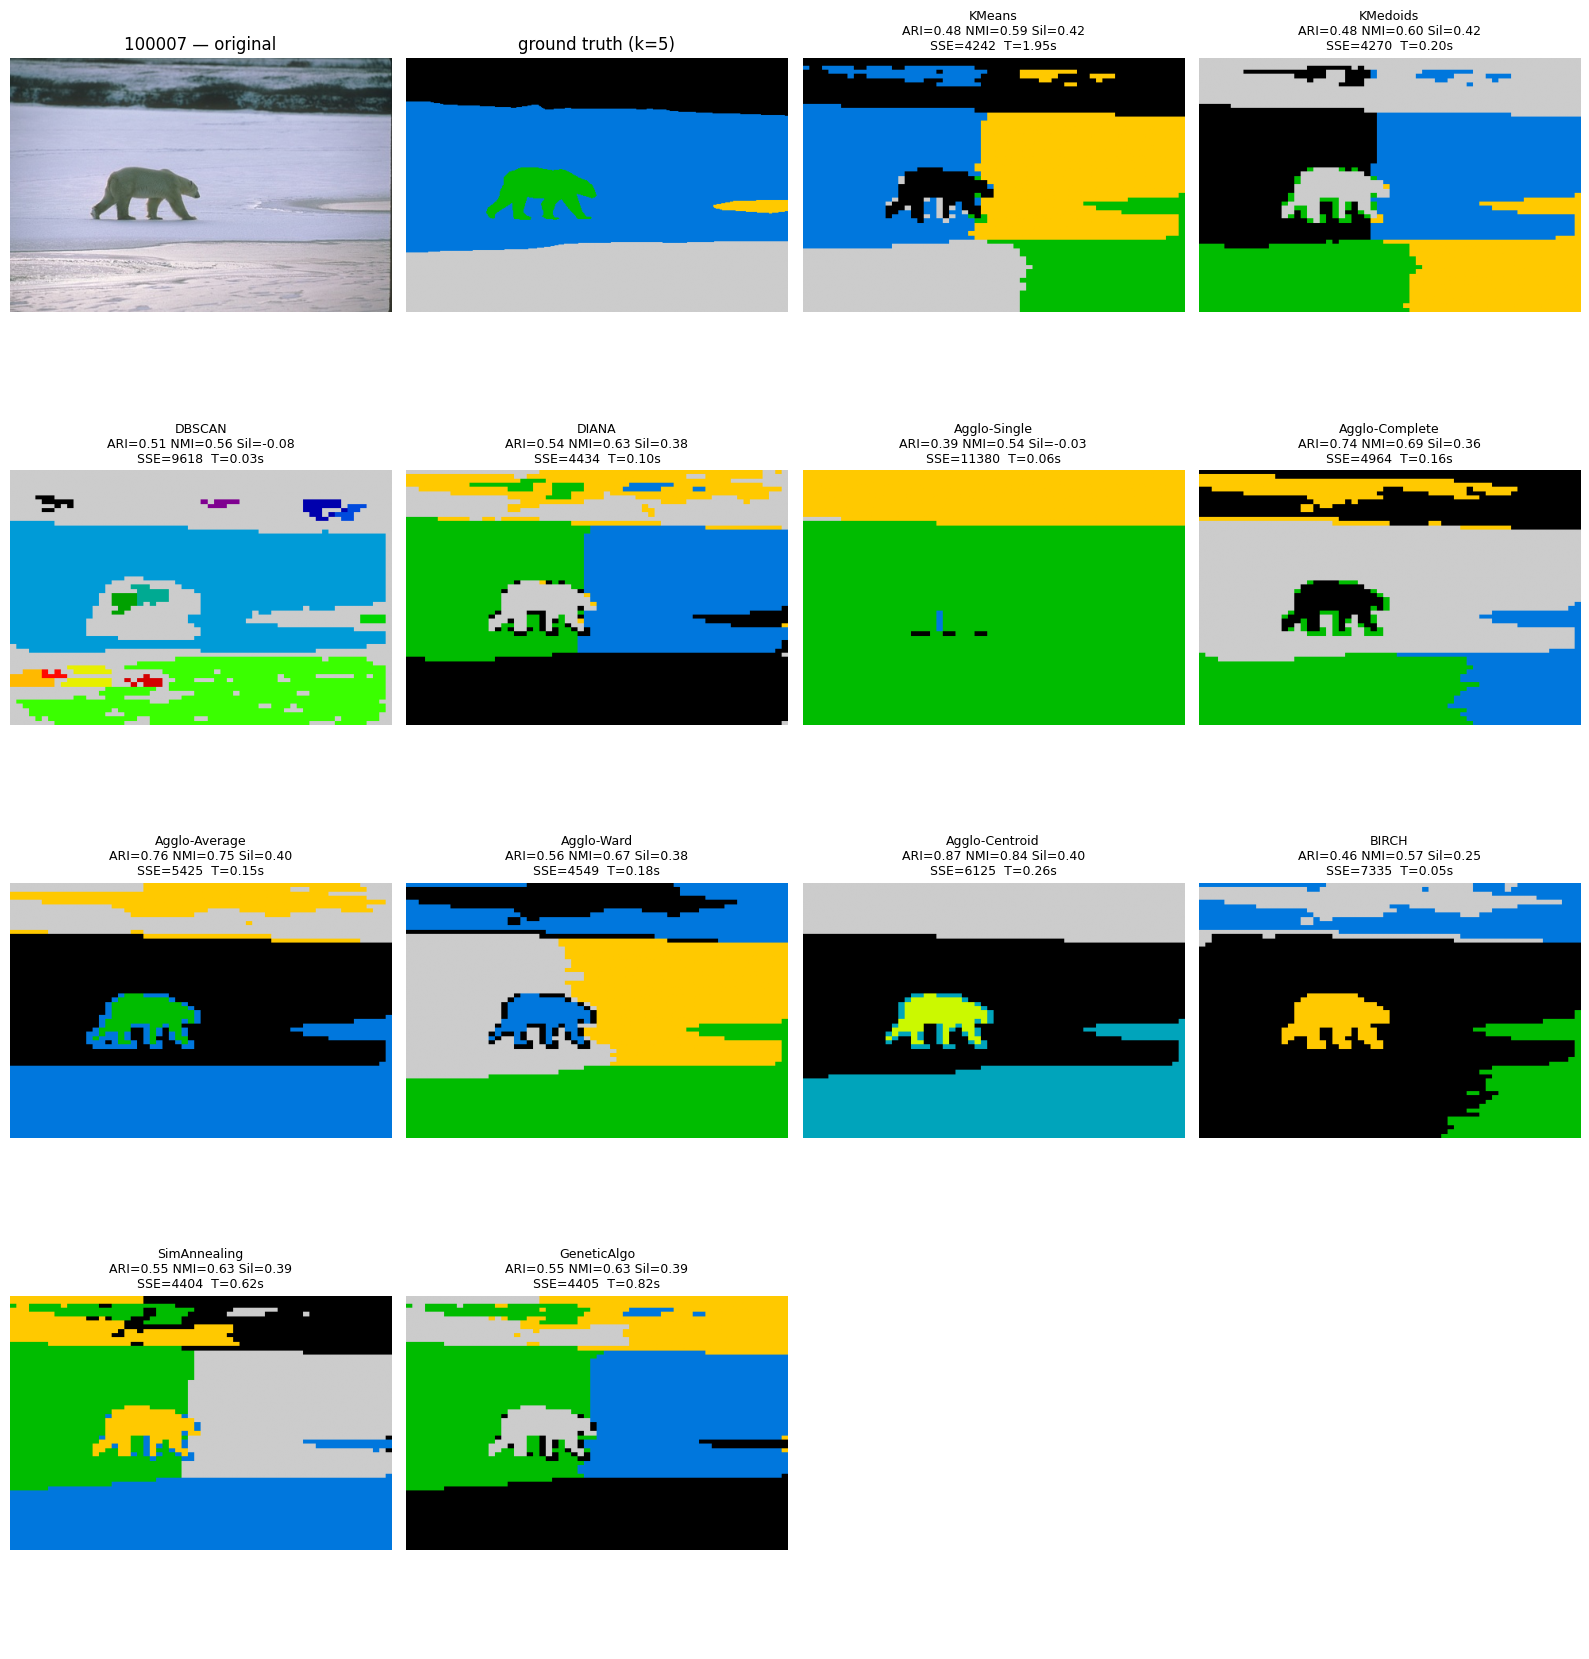

  [100007] saved grid -> clustering_outputs\100007_segmentations.png

=== Processing image: 100039 ===
  image shape=(321, 481, 3), reference clusters k=11
  [100039] running KMeans ...
    KMeans: ARI=0.322  NMI=0.551  Sil=0.349  SSE=3537.2  (0.10s)
  [100039] running KMedoids ...
    KMedoids: ARI=0.350  NMI=0.554  Sil=0.314  SSE=3905.6  (0.17s)
  [100039] running DBSCAN ...
    DBSCAN: ARI=0.274  NMI=0.491  Sil=-0.110  SSE=6952.1  (0.04s)
  [100039] running DIANA ...
    DIANA: ARI=0.297  NMI=0.516  Sil=0.279  SSE=4215.2  (0.24s)
  [100039] running Agglo-Single ...
    Agglo-Single: ARI=-0.001  NMI=0.006  Sil=-0.305  SSE=17882.6  (0.08s)
  [100039] running Agglo-Complete ...
    Agglo-Complete: ARI=0.293  NMI=0.497  Sil=0.255  SSE=4903.6  (0.14s)
  [100039] running Agglo-Average ...
    Agglo-Average: ARI=0.532  NMI=0.678  Sil=0.297  SSE=4926.1  (0.15s)
  [100039] running Agglo-Ward ...
    Agglo-Ward: ARI=0.332  NMI=0.563  Sil=0.314  SSE=3990.9  (0.25s)
  [100039] running Agglo-Cen

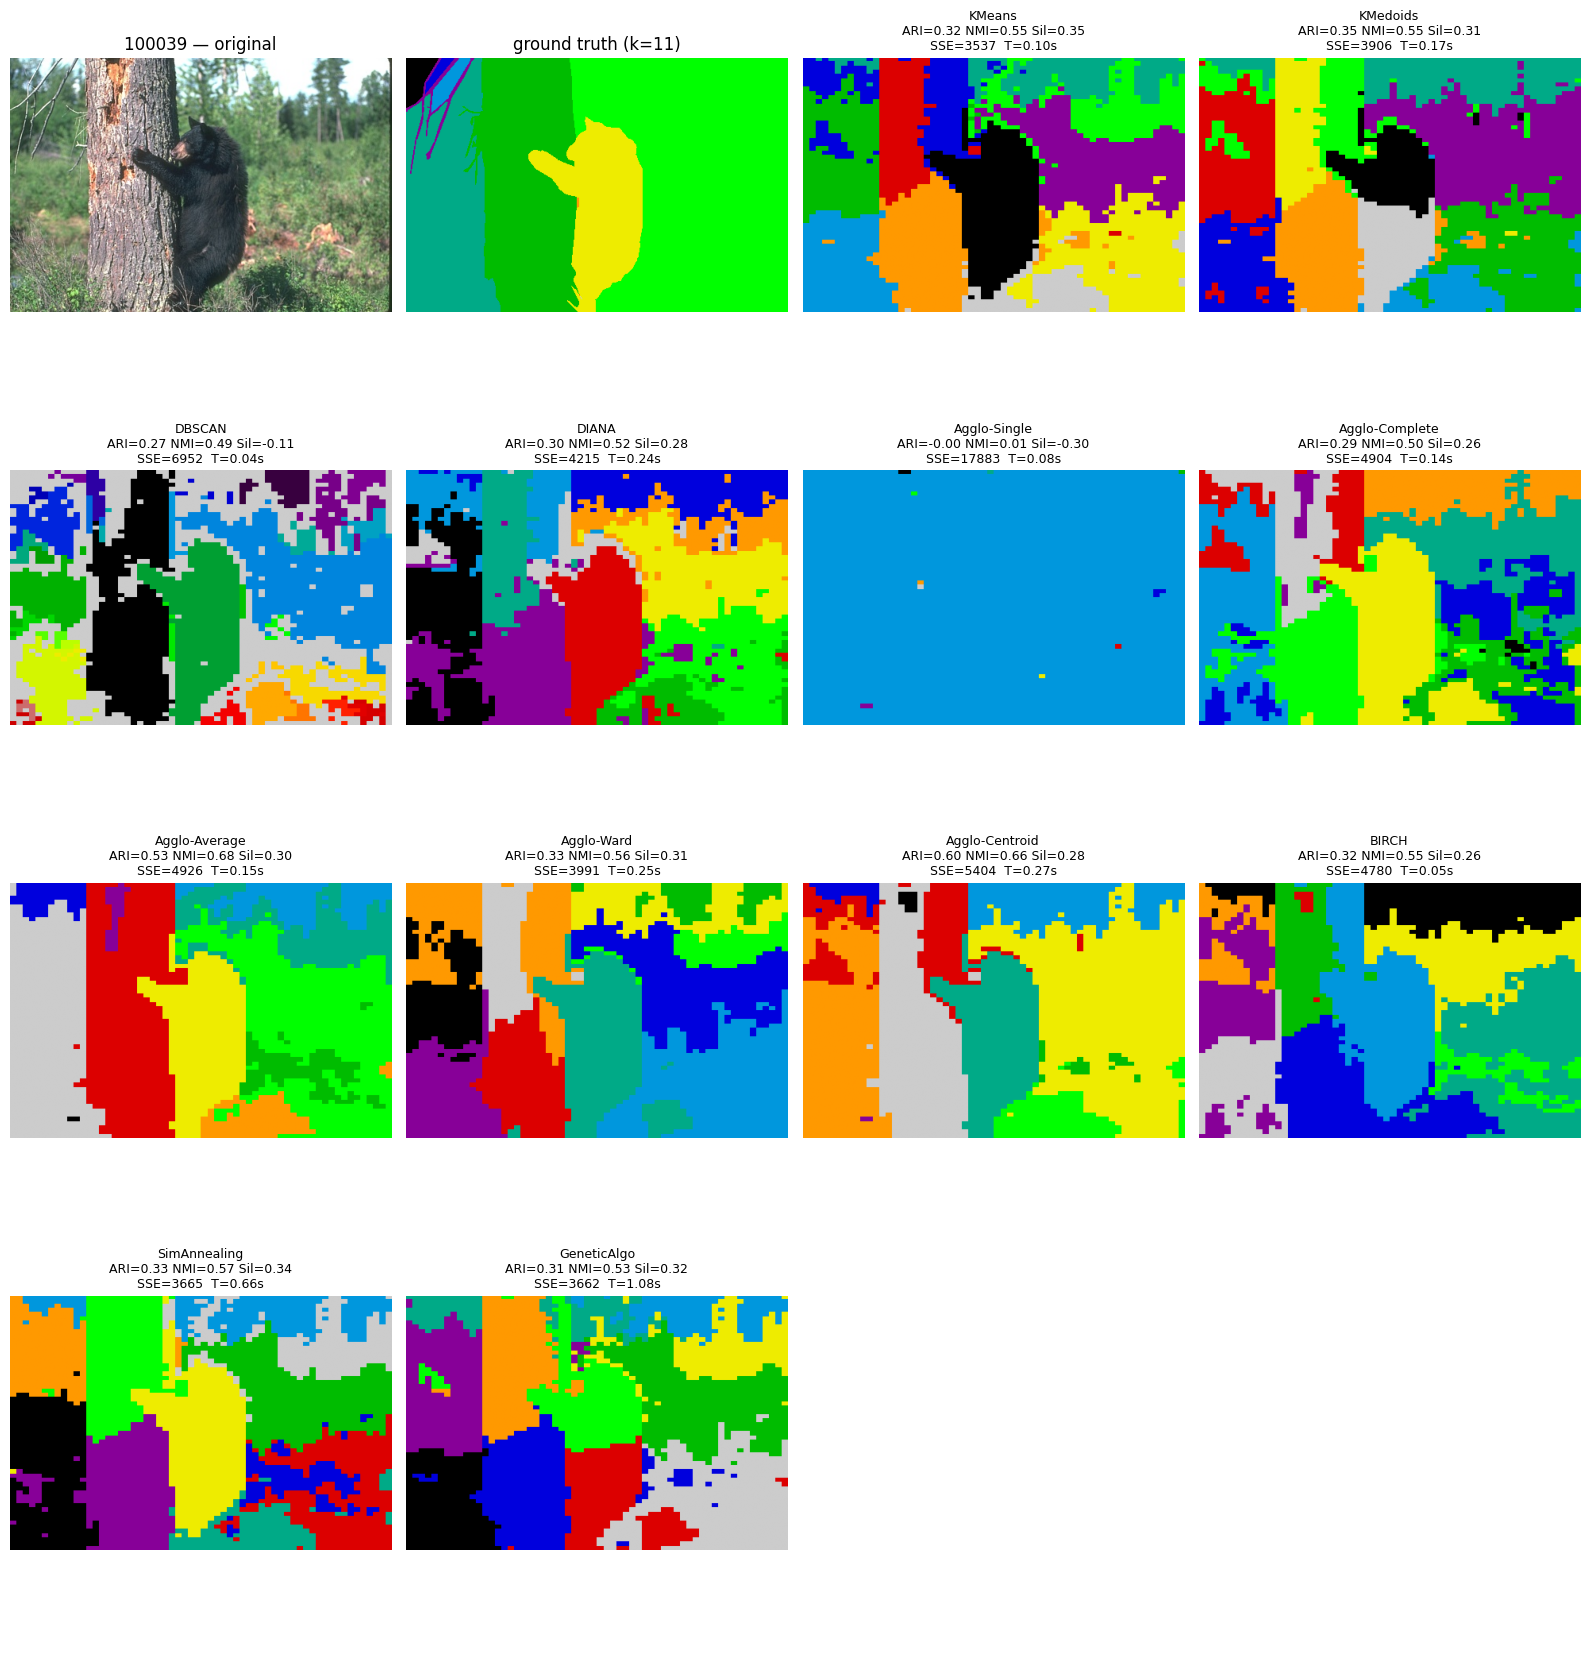

  [100039] saved grid -> clustering_outputs\100039_segmentations.png


=== Full Results Table ===
 Image      Algorithm     ARI    NMI  Silhouette      SSE  Time (s)
100007         KMeans  0.4756 0.5894      0.4166  4241.93     1.955
100007       KMedoids  0.4816 0.5957      0.4160  4270.46     0.200
100007         DBSCAN  0.5073 0.5632     -0.0814  9618.48     0.035
100007          DIANA  0.5392 0.6302      0.3813  4434.20     0.095
100007   Agglo-Single  0.3939 0.5419     -0.0332 11380.03     0.064
100007 Agglo-Complete  0.7420 0.6929      0.3589  4963.65     0.158
100007  Agglo-Average  0.7616 0.7498      0.3953  5425.23     0.147
100007     Agglo-Ward  0.5632 0.6684      0.3784  4548.67     0.180
100007 Agglo-Centroid  0.8687 0.8352      0.3975  6125.10     0.257
100007          BIRCH  0.4649 0.5662      0.2525  7334.73     0.048
100007   SimAnnealing  0.5515 0.6345      0.3885  4404.34     0.618
100007    GeneticAlgo  0.5479 0.6310      0.3877  4405.17     0.817
100039         KMe

,ARI,NMI,Silhouette,SSE,Time (s)
Algorithm,,,,,
KMeans,0.4756,0.5894,0.4166,4241.93,1.955
KMedoids,0.4816,0.5957,0.4160,4270.46,0.200
DBSCAN,0.5073,0.5632,-0.0814,9618.48,0.035
DIANA,0.5392,0.6302,0.3813,4434.20,0.095
Agglo-Single,0.3939,0.5419,-0.0332,11380.03,0.064
Agglo-Complete,0.7420,0.6929,0.3589,4963.65,0.158
Agglo-Average,0.7616,0.7498,0.3953,5425.23,0.147
Agglo-Ward,0.5632,0.6684,0.3784,4548.67,0.180
Agglo-Centroid,0.8687,0.8352,0.3975,6125.10,0.257


,ARI,NMI,Silhouette,SSE,Time (s)
Algorithm,,,,,
KMeans,0.3221,0.5512,0.3489,3537.16,0.096
KMedoids,0.3504,0.5543,0.3143,3905.56,0.167
DBSCAN,0.2745,0.4907,-0.1100,6952.12,0.041
DIANA,0.2969,0.5157,0.2789,4215.25,0.240
Agglo-Single,-0.0006,0.0064,-0.3049,17882.65,0.079
Agglo-Complete,0.2934,0.4973,0.2551,4903.56,0.135
Agglo-Average,0.5323,0.6779,0.2966,4926.12,0.150
Agglo-Ward,0.3322,0.5633,0.3136,3990.88,0.247
Agglo-Centroid,0.5988,0.6650,0.2835,5403.75,0.268


,ARI,NMI,Silhouette,SSE,Time (s),Rank (ARI)
Algorithm,,,,,,
KMeans,0.3989,0.5703,0.3828,3889.55,1.026,9
KMedoids,0.4160,0.5750,0.3651,4088.01,0.183,8
DBSCAN,0.3909,0.5270,-0.0957,8285.30,0.038,11
DIANA,0.4180,0.5730,0.3301,4324.73,0.168,7
Agglo-Single,0.1966,0.2742,-0.1690,14631.34,0.071,12
Agglo-Complete,0.5177,0.5951,0.3070,4933.60,0.146,3
Agglo-Average,0.6470,0.7138,0.3460,5175.68,0.148,2
Agglo-Ward,0.4477,0.6158,0.3460,4269.77,0.213,4
Agglo-Centroid,0.7338,0.7501,0.3405,5764.43,0.263,1



All outputs saved to 'clustering_outputs/':
  100007_segmentations.png
  100039_segmentations.png
  Clustering_Metrics_Comparison.xlsx
  comparison_pivot_ARI.csv
  comparison_pivot_NMI.csv
  comparison_pivot_SSE.csv
  comparison_pivot_Silhouette.csv
  comparison_pivot_Time.csv
  comparison_results.csv
  evaluation_matrix.csv


In [14]:
df = main()

## Average comparison charts (all 12 algorithms)

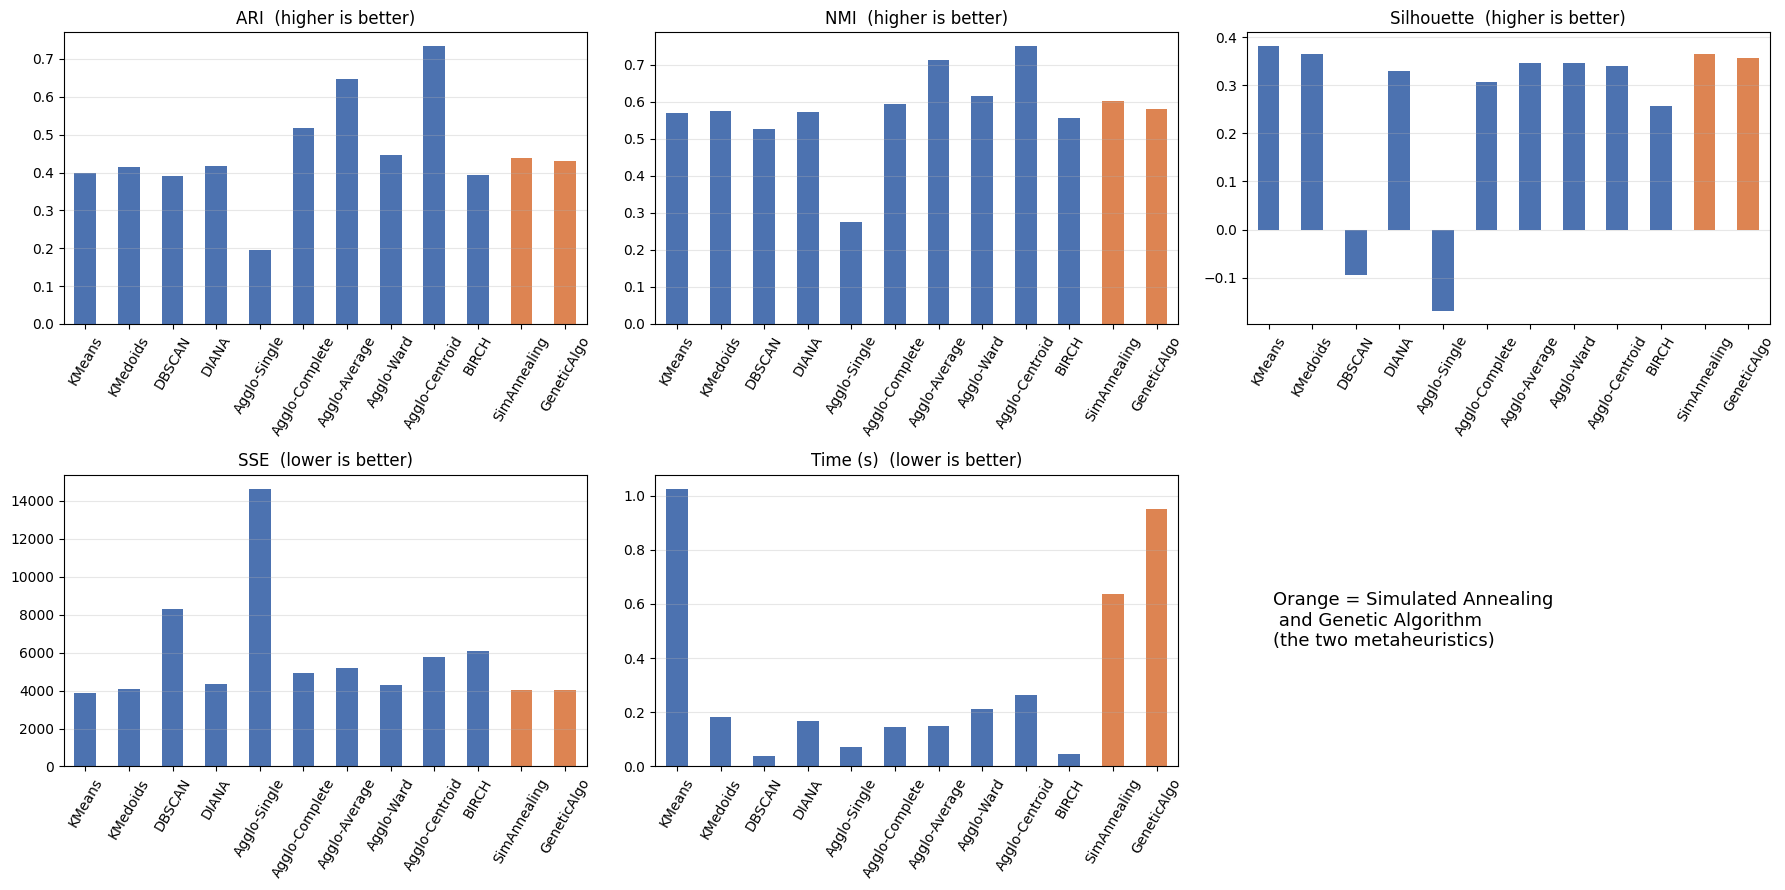

In [15]:
avg = df.groupby("Algorithm")[list(METRICS)].mean().reindex(list(ALGORITHMS.keys()))
colors = ["#DD8452" if a in ("SimAnnealing", "GeneticAlgo") else "#4C72B0" for a in avg.index]  # new methods in orange

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (m, hi) in zip(axes.flatten(), METRICS.items()):
    avg[m].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(f"{m}  ({'higher' if hi else 'lower'} is better)")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=60); ax.grid(axis="y", alpha=.3)
axes.flatten()[-1].axis("off")
axes.flatten()[-1].text(0.05, 0.5, "Orange = Simulated Annealing\n and Genetic Algorithm\n(the two metaheuristics)", fontsize=13, va="center")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "average_metrics_charts.png"), dpi=130)
plt.show()

## SA and GA convergence (cost = SSE vs iteration / generation, last image)

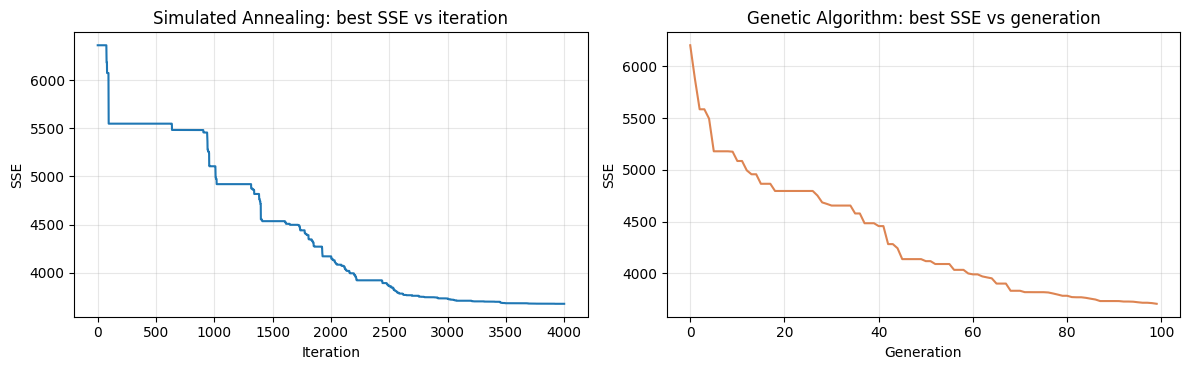

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(CONVERGENCE["SA"]);  ax[0].set_title("Simulated Annealing: best SSE vs iteration"); ax[0].set_xlabel("Iteration")
ax[1].plot(CONVERGENCE["GA"], color="#DD8452"); ax[1].set_title("Genetic Algorithm: best SSE vs generation"); ax[1].set_xlabel("Generation")
for a in ax: a.set_ylabel("SSE"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Automatic summary of the results

In [17]:
best = lambda m: avg[m].idxmax() if METRICS[m] else avg[m].idxmin()
val  = lambda m: avg[m].max()    if METRICS[m] else avg[m].min()
print("=== SUMMARY (averaged over all evaluated images) ===")
for m in METRICS:
    print(f"* Best {m:<10}: {best(m):<15} ({val(m):.4f})")
print()
for a in ("SimAnnealing", "GeneticAlgo"):
    r = avg.loc[a]; rk = avg["ARI"].rank(ascending=False, method="min")[a]
    print(f"* {a}: ARI={r['ARI']:.3f} (rank {int(rk)}/{len(avg)}), NMI={r['NMI']:.3f}, "
          f"Sil={r['Silhouette']:.3f}, SSE={r['SSE']:.1f} "
          f"({r['SSE']/avg.loc['KMeans','SSE']:.2f}x KMeans), Time={r['Time (s)']:.2f}s "
          f"({r['Time (s)']/max(avg.loc['KMeans','Time (s)'],1e-6):.0f}x KMeans)")

=== SUMMARY (averaged over all evaluated images) ===
* Best ARI       : Agglo-Centroid  (0.7338)
* Best NMI       : Agglo-Centroid  (0.7501)
* Best Silhouette: KMeans          (0.3828)
* Best SSE       : KMeans          (3889.5450)
* Best Time (s)  : DBSCAN          (0.0380)

* SimAnnealing: ARI=0.439 (rank 5/12), NMI=0.602, Sil=0.366, SSE=4034.8 (1.04x KMeans), Time=0.64s (1x KMeans)
* GeneticAlgo: ARI=0.430 (rank 6/12), NMI=0.582, Sil=0.356, SSE=4033.5 (1.04x KMeans), Time=0.95s (1x KMeans)
